<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Project_Test4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

# Data preparation
dataset_path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
images_dir = os.path.join(dataset_path, "images", "images")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes
label_map = {v: k for k, v in train_generator.class_indices.items()}

100%|██████████| 2.29G/2.29G [00:25<00:00, 95.5MB/s]

Extracting files...


Found 7042 images belonging to 51 classes.
Found 1732 images belonging to 51 classes.


In [3]:
# Build the model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer=optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_initial = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 96s 397ms/step - accuracy: 0.0929 - loss: 3.7280 - val_accuracy: 0.1357 - val_loss: 3.4629
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 79s 357ms/step - accuracy: 0.1358 - loss: 3.4586 - val_accuracy: 0.1703 - val_loss: 3.2983
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 77s 349ms/step - accuracy: 0.1752 - loss: 3.2870 - val_accuracy: 0.2003 - val_loss: 3.1617
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 77s 347ms/step - accuracy: 0.2022 - loss: 3.1603 - val_accuracy: 0.2500 - val_loss: 3.0502
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 77s 348ms/step - accuracy: 0.2244 - loss: 3.0506 - val_accuracy: 0.2587 - val_loss: 2.9472
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 75s 340ms/step - accuracy: 0.2441 - loss: 2.9424 - val_accuracy: 0.2806 - val_loss: 2.8629
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 76s 345ms/step - accuracy: 0.2637 - loss: 2.8608 - val_accuracy: 0.2870 - val_loss: 2.7963
Epoch 8/20
221/221 ━━━━━━━━━━━━━

In [4]:
# Fine tune
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(1e-6), loss='categorical_crossentropy', metrics=['accuracy'])
history_finetune = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 94s 400ms/step - accuracy: 0.3899 - loss: 2.2529 - val_accuracy: 0.3828 - val_loss: 2.2864
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 82s 370ms/step - accuracy: 0.3956 - loss: 2.1881 - val_accuracy: 0.3943 - val_loss: 2.2514
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 82s 370ms/step - accuracy: 0.4141 - loss: 2.1419 - val_accuracy: 0.4042 - val_loss: 2.2181
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 82s 372ms/step - accuracy: 0.4174 - loss: 2.1291 - val_accuracy: 0.4036 - val_loss: 2.1948
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 82s 371ms/step - accuracy: 0.4232 - loss: 2.0890 - val_accuracy: 0.4128 - val_loss: 2.1803
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 83s 375ms/step - accuracy: 0.4218 - loss: 2.0693 - val_accuracy: 0.4128 - val_loss: 2.1603
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 84s 379ms/step - accuracy: 0.4338 - loss: 2.0537 - val_accuracy: 0.4111 - val_loss: 2.1633
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 85s 383ms/step - accuracy: 0.4335 - loss: 2

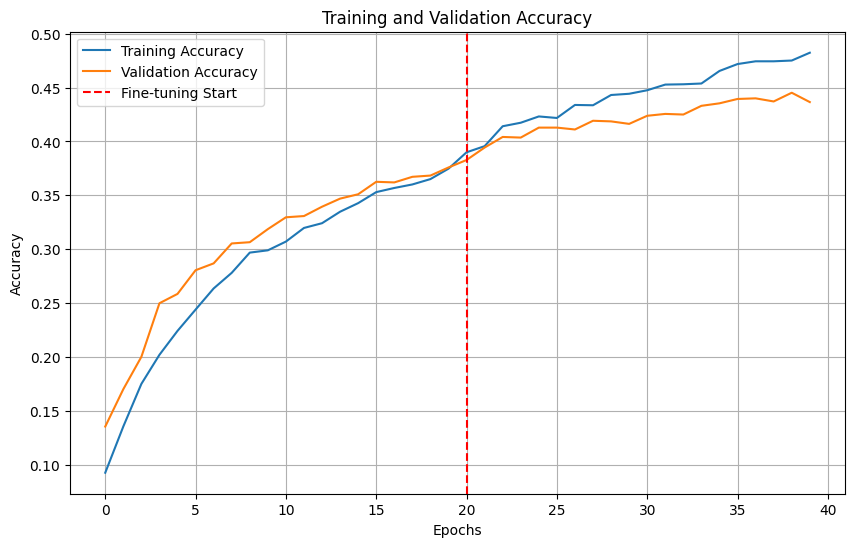

In [5]:
# Visualize the accuracy curve
acc = history_initial.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_finetune.history['val_accuracy']

plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=20, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


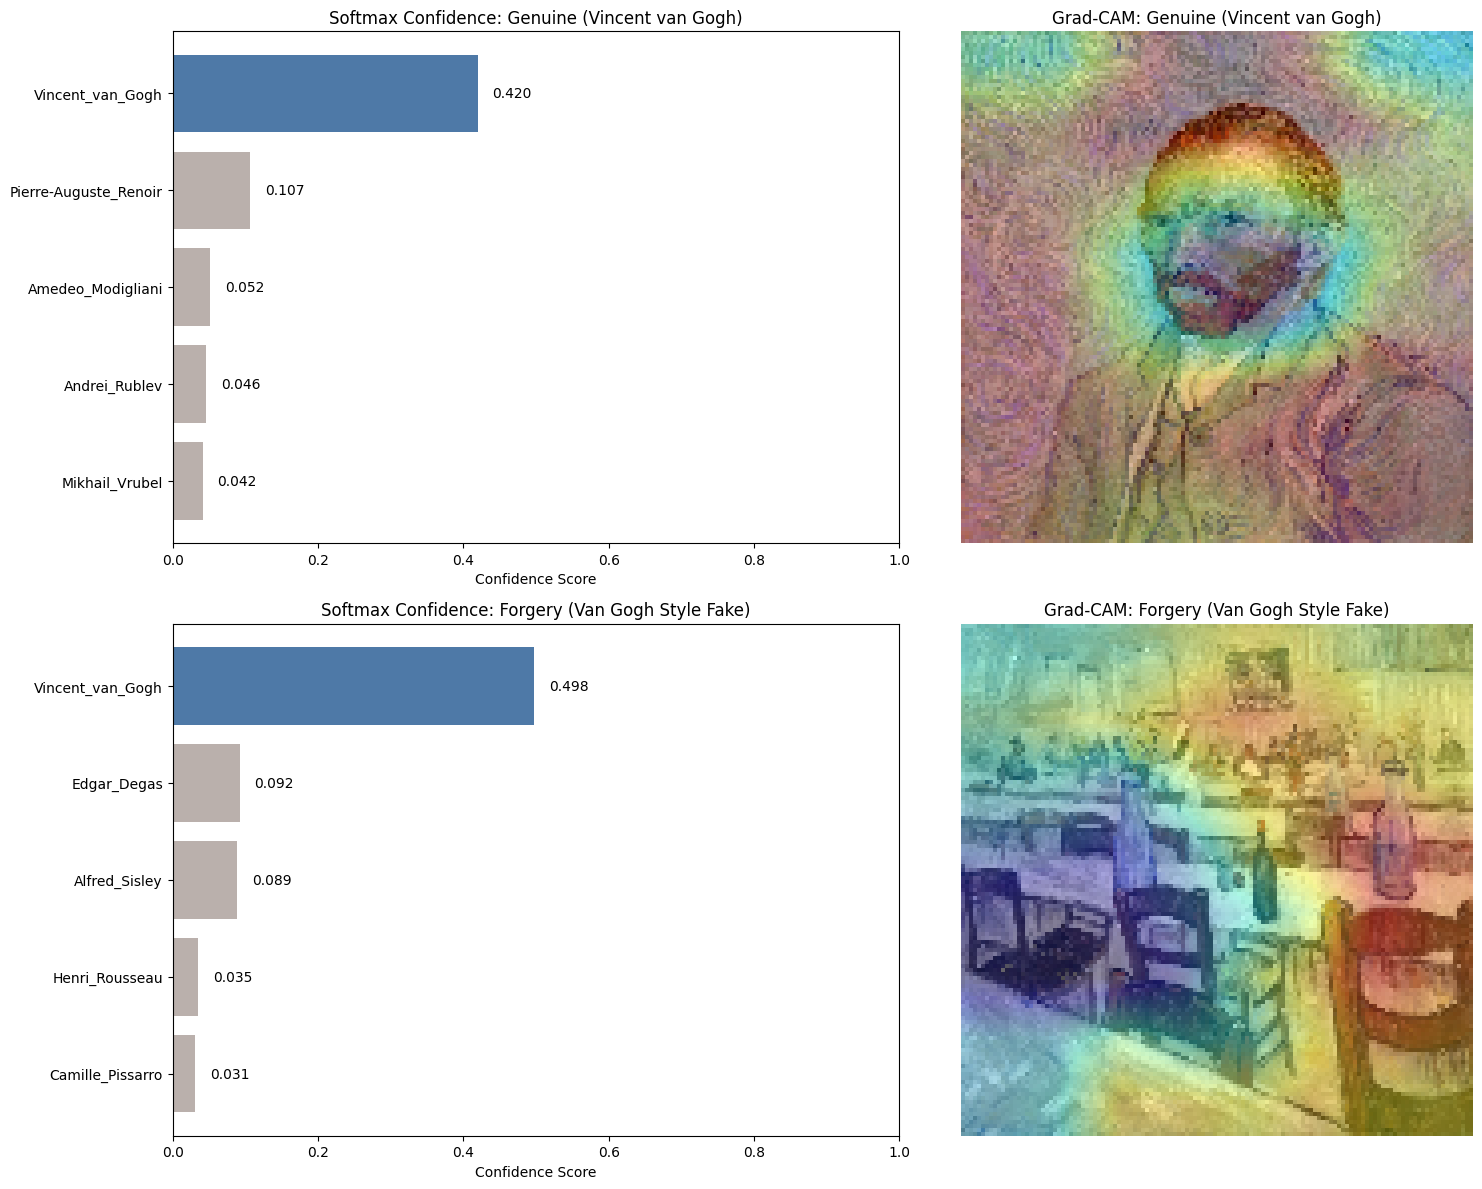

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        vgg16_base = model.get_layer('vgg16')

        feature_extractor_model = tf.keras.Model(
            inputs=vgg16_base.input,
            outputs=vgg16_base.get_layer(last_conv_layer_name).output
        )

        features = feature_extractor_model(img_tensor)
        tape.watch(features)

        x = features
        for layer in model.layers[model.layers.index(vgg16_base) + 1:]:
            x = layer(x)

        preds = x
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, features)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = features[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def get_top5_predictions(img_array, model, label_map):
    preds = model.predict(img_array)[0]
    top_indices = np.argsort(preds)[-5:][::-1]
    top5_labels = [label_map[i] for i in top_indices]
    top5_confidences = [preds[i] for i in top_indices]
    return top5_labels, top5_confidences

def run_forensic_analysis(genuine_path, fake_path, model, label_map, layer_name):
    IMG_SIZE = (128, 128)
    paths = [genuine_path, fake_path]
    titles = ["Genuine (Vincent van Gogh)", "Forgery (Van Gogh Style Fake)"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    for i, path in enumerate(paths):
        img = image.load_img(path, target_size=IMG_SIZE)
        img_array = image.img_to_array(img) / 255.0
        img_array_input = np.expand_dims(img_array, axis=0)

        labels, confs = get_top5_predictions(img_array_input, model, label_map)
        ax_conf = axes[i, 0]
        y_pos = np.arange(len(labels))
        bars = ax_conf.barh(y_pos, confs, align='center', color=['#4e79a7' if c > 0.4 else '#bab0ac' for c in confs])
        ax_conf.set_yticks(y_pos)
        ax_conf.set_yticklabels(labels)
        ax_conf.invert_yaxis()
        ax_conf.set_xlabel('Confidence Score')
        ax_conf.set_title(f'Softmax Confidence: {titles[i]}')
        ax_conf.set_xlim(0, 1.0)
        for bar, conf in zip(bars, confs):
            ax_conf.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{conf:.3f}', va='center')

        heatmap = make_gradcam_heatmap(img_array_input, model, layer_name)
        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
        heatmap_cv2 = np.uint8(255 * heatmap_resized)
        heatmap_color = cv2.applyColorMap(heatmap_cv2, cv2.COLORMAP_JET)
        superimposed_img = heatmap_color / 255.0 * 0.4 + img_array
        superimposed_img = superimposed_img / np.max(superimposed_img)

        ax_cam = axes[i, 1]
        ax_cam.imshow(superimposed_img)
        ax_cam.set_title(f'Grad-CAM: {titles[i]}')
        ax_cam.axis('off')

    plt.tight_layout()
    plt.savefig('forensic_vangogh_comparison.png')
    plt.show()

LAST_CONV_LAYER = 'block5_conv3'

run_forensic_analysis(
    'Van_Gogh_real.jpg',
    'Van_Gogh_fake.png',
    model,
    label_map,
    LAST_CONV_LAYER
)